# Exploring the residual powerspectrum for fields with identical powerspectra

Powerspectra discard phase information, and thus multiple realisations of a field can have identical powerspectra. The question is whether the powerspectra of the residuals between fields with identical PS can tell us anything about the difference in their morphology

In [16]:
import numpy as np
import cmasher as cmr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap as LSC

prd = LSC.from_list("pride", cmr.pride(np.linspace(0.1, 0.9, 256)))
prd.set_under("white")

In [31]:
def power_spectrum_1d(field, nbins=32, dx=1.0):
    """
    Compute the azimuthally averaged 1D power spectrum of a 2D field.

    Parameters
    ----------
    field : np.ndarray
        2D input field.
    nbins : int
        Number of radial Fourier bins.
    dx : float
        Pixel spacing.

    Returns
    -------
    k_centres : np.ndarray
        Bin centres in Fourier wavenumber units.
    ps_1d : np.ndarray
        Radially averaged power spectrum.
    """
    field = np.asarray(field)

    if field.ndim != 2:
        raise ValueError("field must be a 2D array")

    ny, nx = field.shape

    ft = np.fft.fft2(field)
    ps_2d = np.abs(ft) ** 2

    kx = np.fft.fftfreq(nx, d=dx)
    ky = np.fft.fftfreq(ny, d=dx)

    kx_grid, ky_grid = np.meshgrid(kx, ky)
    k_radius = np.sqrt(kx_grid**2 + ky_grid**2)

    k_flat = k_radius.ravel()
    ps_flat = ps_2d.ravel()

    bin_edges = np.linspace(0, k_flat.max(), nbins + 1)
    bin_indices = np.digitize(k_flat, bin_edges) - 1

    ps_1d = np.full(nbins, np.nan)
    k_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    for i in range(nbins):
        mask = bin_indices == i
        if np.any(mask):
            ps_1d[i] = ps_flat[mask].mean()

    return k_centres, ps_1d

## Let's start with a very simple case

Power spectrum is phase agnostic. This means that for a simple binary field, translation of all points should preserve the PS. But what about the PS of the residuals?

Let's generate a 512x512 grid, and make a circle of pixels of 64 pixels on it. This will be out first field. We can translate the circle to form our second field. In principle the fields should have identical PS.

In [25]:
def circle_points(centre, radius, npix):
    """
    Generate integer pixel coordinates along a circle.

    Parameters
    ----------
    centre : tuple[float, float]
        Circle centre (x, y).
    radius : float
        Circle radius in pixels.
    npix : int
        Number of points around the circumference.

    Returns
    -------
    xpix : np.ndarray
        Integer x coordinates.
    ypix : np.ndarray
        Integer y coordinates.
    """
    cx, cy = centre

    theta = np.linspace(0, 2 * np.pi, npix, endpoint=False)

    xpix = np.rint(cx + radius * np.cos(theta)).astype(int)
    ypix = np.rint(cy + radius * np.sin(theta)).astype(int)

    return xpix, ypix

In [93]:
x1, y1 = circle_points(centre=(128, 128), radius=64, npix=128)
x2, y2 = circle_points(centre=(128, 184), radius=64, npix=128)

In [94]:
field1 = np.zeros((256, 256), dtype=float)
field1[y1, x1] = 1.0

field2 = np.zeros((256, 256), dtype=float)
field2[y2, x2] = 1.0

residual = field1 - field2

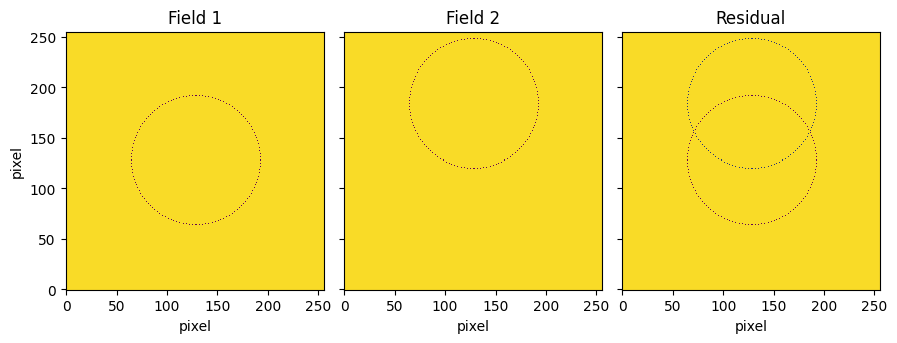

In [95]:
fig, axs = plt.subplots(1, 3, figsize=(9, 4), sharey=True)

axs[0].imshow(field1, origin="lower", cmap=prd, vmin=-1, vmax=1, interpolation="none")
axs[1].imshow(field2, origin="lower", cmap=prd, vmin=-1, vmax=1, interpolation="none")
axs[2].imshow(residual, origin="lower", cmap=prd, vmin=-1, vmax=1, interpolation="none")

axs[0].set_ylabel("pixel")

lab = ["Field 1", "Field 2", "Residual"]
for i, ax in enumerate(axs):
    ax.set_xlabel("pixel")
    ax.set_title(lab[i])

plt.tight_layout()
plt.show()

In [96]:
k1, p1 = power_spectrum_1d(field1, nbins=64)
k2, p2 = power_spectrum_1d(field2, nbins=64)
kr, pr = power_spectrum_1d(residual, nbins=64)

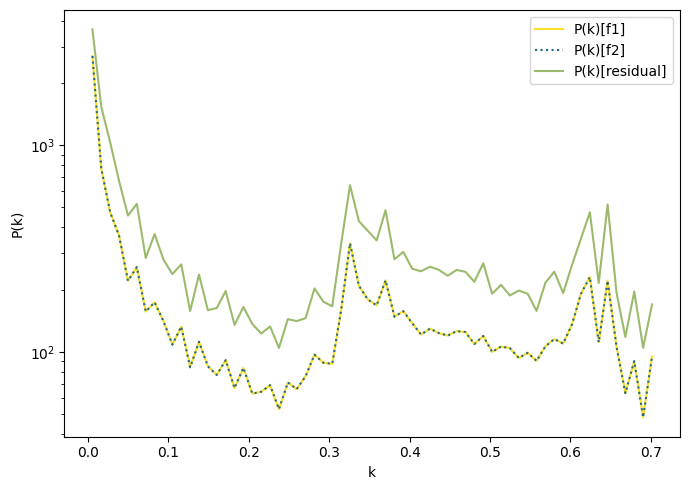

In [97]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.semilogy(k1, p1, color=cmr.pride(0.5), label="P(k)[f1]")
ax.semilogy(k2, p2, color=cmr.pride(0.2), ls=":", label="P(k)[f2]")
ax.semilogy(kr, pr, color=cmr.pride(0.4), label="P(k)[residual]")

plt.legend()

ax.set_ylabel("P(k)")
ax.set_xlabel("k")

plt.tight_layout()
plt.show()

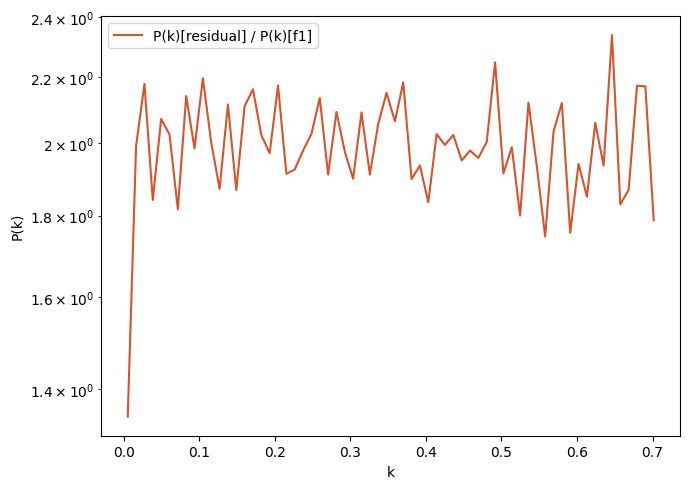

In [102]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.semilogy(kr, pr / p1, color=cmr.pride(0.7), label="P(k)[residual] / P(k)[f1]")

plt.legend()

ax.set_ylabel("P(k)")
ax.set_xlabel("k")

plt.tight_layout()
plt.show()

## Residual Power Spectra and Phase Information

The goal of this demonstration is to investigate whether two fields can have identical power spectra while still being different in real space.

Suppose we construct two fields, $f_1(\mathbf{x})$ and $f_2(\mathbf{x})$, with identical power spectra. We then form the residual

$$
r(\mathbf{x}) = f_1(\mathbf{x}) - f_2(\mathbf{x}),
$$

and compute its power spectrum,

$$
P_r(\mathbf{k}) = |\tilde r(\mathbf{k})|^2.
$$

If the residual power spectrum is non-zero, this immediately demonstrates that the two fields are not identical, despite having the same individual power spectra.

### Fourier Representation

Write the Fourier transforms of the two fields as

$$
\tilde f_1(\mathbf{k})
=
A(\mathbf{k})\,e^{i\phi_1(\mathbf{k})},
$$

and

$$
\tilde f_2(\mathbf{k})
=
A(\mathbf{k})\,e^{i\phi_2(\mathbf{k})},
$$

where the amplitudes are identical because the power spectra are identical:

$$
P(\mathbf{k})
=
|\tilde f_1(\mathbf{k})|^2
=
|\tilde f_2(\mathbf{k})|^2
=
A^2(\mathbf{k}).
$$

The residual in Fourier space is therefore

$$
\tilde r(\mathbf{k})
=
A(\mathbf{k})
\left[
e^{i\phi_1(\mathbf{k})}
-
e^{i\phi_2(\mathbf{k})}
\right].
$$

Its power spectrum becomes

$$
P_r(\mathbf{k})
=
A^2(\mathbf{k})
\left|
e^{i\phi_1}
-
e^{i\phi_2}
\right|^2.
$$

Using the identity

$$
|e^{ia}-e^{ib}|^2
=
2-2\cos(a-b),
$$

we obtain

$$
P_r(\mathbf{k})
=
2P(\mathbf{k})
\left[
1-\cos\bigl(\Delta\phi(\mathbf{k})\bigr)
\right],
$$

where

$$
\Delta\phi(\mathbf{k})
=
\phi_1(\mathbf{k})
-
\phi_2(\mathbf{k}).
$$

Using

$$
1-\cos\theta
=
2\sin^2\left(\frac{\theta}{2}\right),
$$

gives

$$
P_r(\mathbf{k})
=
4P(\mathbf{k})
\sin^2\!\left(
\frac{\Delta\phi(\mathbf{k})}{2}
\right).
$$

This result shows that the residual power spectrum depends entirely on the phase differences between the two fields. The original power spectra are blind to phase information, whereas the residual power spectrum is explicitly sensitive to it.

### Special Case: A Pure Translation

In this example, the second field is simply a translated version of the first:

$$
f_2(\mathbf{x})
=
f_1(\mathbf{x}-\Delta\mathbf{x}).
$$

The Fourier shift theorem gives

$$
\tilde f_2(\mathbf{k})
=
\tilde f_1(\mathbf{k})
e^{-i\mathbf{k}\cdot\Delta\mathbf{x}}.
$$

The phase difference is therefore

$$
\Delta\phi(\mathbf{k})
=
\mathbf{k}\cdot\Delta\mathbf{x},
$$

and the residual power spectrum becomes

$$
P_r(\mathbf{k})
=
4P(\mathbf{k})
\sin^2\!\left(
\frac{\mathbf{k}\cdot\Delta\mathbf{x}}{2}
\right).
$$

Consequently,

$$
\frac{P_r(\mathbf{k})}{P(\mathbf{k})}
=
4\sin^2\!\left(
\frac{\mathbf{k}\cdot\Delta\mathbf{x}}{2}
\right).
$$

### Why Does the Spherically Averaged Ratio Approach 2?

The expression above depends on the direction of $\mathbf{k}$ through the dot product $\mathbf{k}\cdot\Delta\mathbf{x}$.

When computing a one-dimensional power spectrum, we average over all Fourier modes with the same magnitude $k = |\mathbf{k}|$. This angular averaging samples many values of the phase difference, causing

$$
\sin^2\!\left(
\frac{\mathbf{k}\cdot\Delta\mathbf{x}}{2}
\right)
$$

to oscillate between 0 and 1.

The average value of $\sin^2$ over a complete cycle is

$$
\left\langle \sin^2 \theta \right\rangle
=
\frac{1}{2}.
$$

Therefore, after spherical averaging,

$$
\left\langle
\frac{P_r(k)}{P(k)}
\right\rangle
=
4
\left\langle
\sin^2 \theta
\right\rangle
=
4\times\frac{1}{2}
=
2.
$$

This explains the numerical result observed above: although the two translated fields have identical power spectra, the residual power spectrum contains approximately twice as much power as either individual field after angular averaging.

This provides a simple demonstration that two fields can have identical power spectra while still being distinct in real space. The missing information is encoded in the Fourier phases, which are discarded when forming the power spectrum.

## Maybe a 2D PS tells us more?

The math above says that we're losing information is the sperical averaging. Perhaps we should look at the 2D PS? We should at least see the phase ramp from translation?

In [103]:
def power_spectrum_2d(field, shift=True):
    ft = np.fft.fft2(field)
    ps = np.abs(ft) ** 2

    if shift:
        ps = np.fft.fftshift(ps)

    return ps

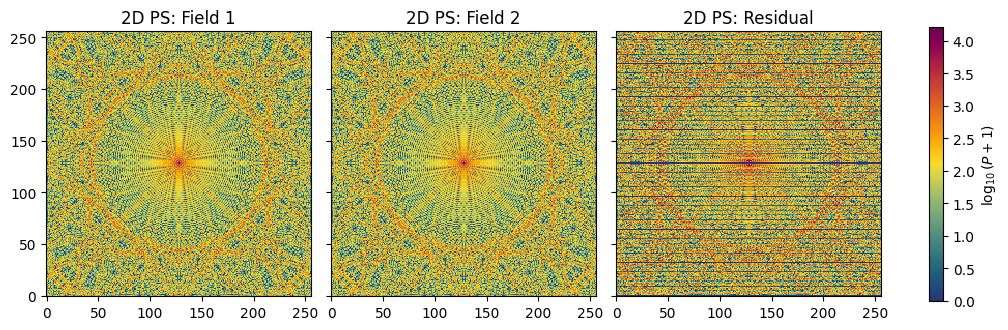

In [112]:
ps1_2d = power_spectrum_2d(field1)
ps2_2d = power_spectrum_2d(field2)
psr_2d = power_spectrum_2d(residual)

ps_list = [
    np.log10(ps1_2d + 1),
    np.log10(ps2_2d + 1),
    np.log10(psr_2d + 1),
]

vmin = min(ps.min() for ps in ps_list)
vmax = max(ps.max() for ps in ps_list)

fig, axs = plt.subplots(
    1, 3,
    figsize=(10, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, ps, title in zip(axs, ps_list, ["2D PS: Field 1", "2D PS: Field 2", "2D PS: Residual"]):
    im = ax.imshow(
        ps,
        origin="lower",
        cmap=prd,
        vmin=vmin,
        vmax=vmax,
        interpolation="none",
    )
    ax.set_title(title)

cbar = fig.colorbar(
    im,
    ax=axs,
    shrink=0.7,
    label=r"$\log_{10}(P+1)$",
)

plt.show()

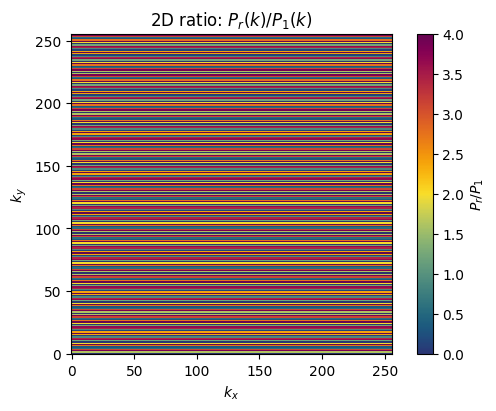

In [117]:
ratio_2d = psr_2d / (ps1_2d)

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

im = ax.imshow(
    ratio_2d,
    origin="lower",
    interpolation="none",
    cmap=prd,
)

ax.set_title(r"2D ratio: $P_r(k) / P_1(k)$")
ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")

fig.colorbar(im, ax=ax, label=r"$P_r / P_1$")

plt.show()

What we’re seeing is almost exactly the analytic prediction:

$$
\frac{P_r(\mathbf{k})}{P_1(\mathbf{k})}
=
4\sin^2\left(\frac{\mathbf{k}\cdot\Delta\mathbf{x}}{2}\right).
$$

For your vertical shift, $\Delta\mathbf{x}=(0,\Delta y)$, so

$$
\mathbf{k}\cdot\Delta\mathbf{x}
=
k_y \Delta y.
$$

Hence

$$
\frac{P_r(\mathbf{k})}{P_1(\mathbf{k})}
=
4\sin^2\left(\frac{k_y\Delta y}{2}\right),
$$

which is:

* independent of k_x,
* oscillatory in k_y,
* bounded between 0 and 4.